# The Starvation Spiral: Why Standard DDA Breaks in Risk-Reward Games
## Cyber Drift Infinite — DDA Simulation & Failure Case

**CSYE 7270 — Take-Home Midterm | Category B: AI in Game Mechanics**

**Topic Claim:** After reading this piece, a practitioner will understand how AI-driven difficulty scaling interacts with risk-reward mechanics like Cyber Drift Infinite's near-miss orb system well enough to design a DDA system that adapts challenge without disrupting the player's resource economy — without making the mistake of treating traffic density as a single-purpose difficulty knob when it simultaneously serves as the player's only path to their power-up.

---

### ⚡ Quick Start — Trigger the Failure Case

1. **Run all cells** in order (Runtime → Run All)
2. **Section 6** shows the starvation spiral across 8 runs under Naive DDA
3. **Section 7** compares Naive DDA vs. Coupling-Aware DDA side by side
4. **Section 8 (The Exercise):** modify `oncoming_ratio_shift` and find the threshold
5. **Human Decision Node** is in the `CouplingAwareDDA` class cell

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Game Configuration

All values come directly from the Cyber Drift Infinite GDD.  
Two-lane endless driver: right lane = same-direction traffic, left lane = oncoming.  
Player cannot brake. Speed ramps from 18 to ~50 units/sec on a smooth curve tied to distance.  
**One variable (`currentSpeed`) drives both player velocity and traffic spawn spacing.**

In [20]:
@dataclass
class GameConfig:
    """Core parameters from the Cyber Drift Infinite GDD."""

    # Speed (units/sec)
    min_speed: float = 18.0
    max_speed: float = 50.0

    # Stage thresholds (meters)
    stage_2_start: float = 1000.0
    stage_3_start: float = 3000.0

    # Traffic density (cars per 100 meters of road)
    base_density_stage1: float = 2.0
    base_density_stage2: float = 4.5
    base_density_stage3: float = 6.5

    # Near-miss orb
    orb_max: float = 100.0
    orb_charge_same_dir: float = 10.0
    orb_charge_oncoming: float = 15.0

    # Rage Mode
    rage_duration: float = 8.0

    # Near-miss probabilities (derived from 0.5-unit trigger zone)
    near_miss_chance_same: float = 0.35
    near_miss_chance_oncoming: float = 0.22

    # Crash probability per car encountered
    base_crash_chance: float = 0.018

    # Oncoming traffic fraction
    oncoming_fraction: float = 0.35

    # Stage 3: no-safe-lane formation chance
    no_safe_lane_chance_per_sec: float = 0.04

    # Base gap width and barrier frequency
    base_gap_width: float = 1.0
    base_barrier_freq: float = 1.5

cfg = GameConfig()

print("✓ Game config loaded: Cyber Drift Infinite")
print(f"  Speed range:  {cfg.min_speed} – {cfg.max_speed} units/sec")
print(f"  Orb charge:   +{cfg.orb_charge_same_dir} (same-dir), +{cfg.orb_charge_oncoming} (oncoming)")
print(f"  Stages:       {cfg.stage_2_start}m → {cfg.stage_3_start}m")
print(f"  Oncoming %:   {cfg.oncoming_fraction*100:.0f}%")

✓ Game config loaded: Cyber Drift Infinite
  Speed range:  18.0 – 50.0 units/sec
  Orb charge:   +10.0 (same-dir), +15.0 (oncoming)
  Stages:       1000.0m → 3000.0m
  Oncoming %:   35%


## 2. The Fixed Difficulty Curve (Baseline)

### Design Decision: Why the baseline is a fixed curve

Cyber Drift Infinite uses a **deterministic** difficulty system — `currentSpeed` is evaluated from an AnimationCurve against distance. This single variable drives **both** player velocity **and** traffic spawn spacing. Every player who reaches 2,500m faces the same road.

The fixed curve is brutal but honest — improvement is genuine because the challenge doesn't bend to meet the player.

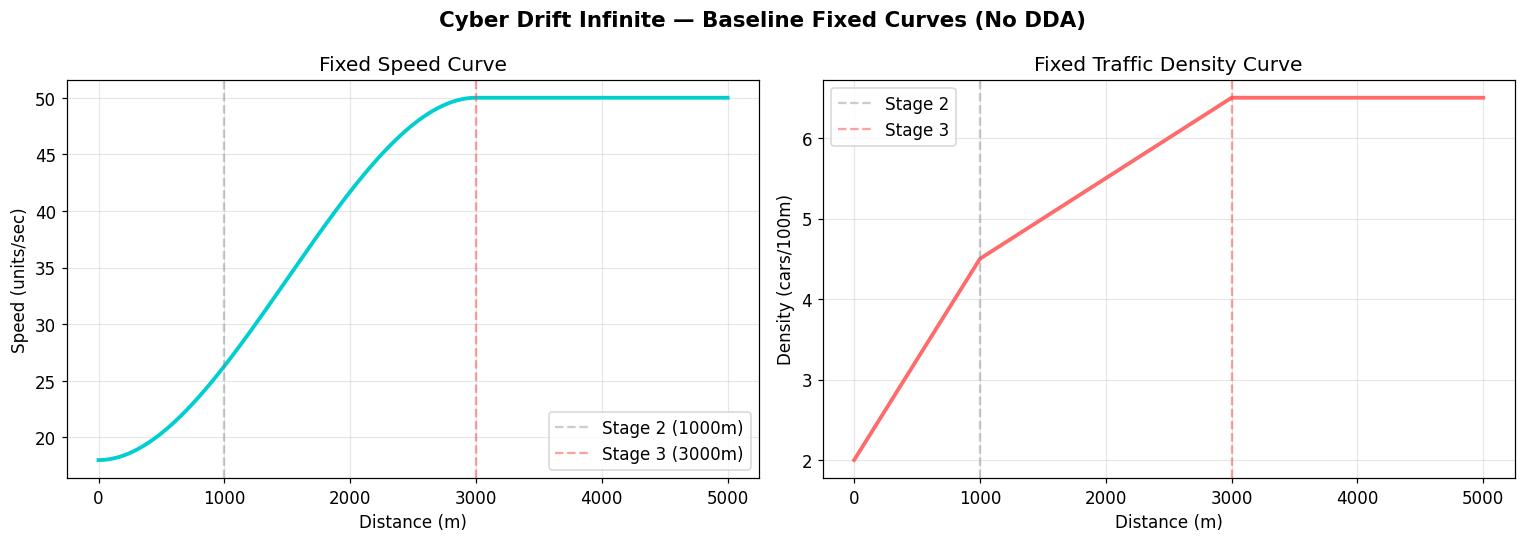

In [21]:
def speed_curve(distance: float) -> float:
    """Speed as f(distance) — smooth S-curve mimicking the GDD's AnimationCurve."""
    t = np.clip(distance / cfg.stage_3_start, 0.0, 1.0)
    smooth = t * t * (3 - 2 * t)
    return cfg.min_speed + (cfg.max_speed - cfg.min_speed) * smooth

def base_traffic_density(distance: float) -> float:
    """Traffic density from the fixed curve — ramps with stage progression."""
    if distance < cfg.stage_2_start:
        t = distance / cfg.stage_2_start
        return cfg.base_density_stage1 + (cfg.base_density_stage2 - cfg.base_density_stage1) * t
    elif distance < cfg.stage_3_start:
        t = (distance - cfg.stage_2_start) / (cfg.stage_3_start - cfg.stage_2_start)
        return cfg.base_density_stage2 + (cfg.base_density_stage3 - cfg.base_density_stage2) * t
    else:
        return cfg.base_density_stage3

# --- Graph: Fixed Curves ---
dist = np.linspace(0, 5000, 500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(dist, [speed_curve(d) for d in dist], color='#00CED1', lw=2.5)
ax1.axvline(1000, color='gray', ls='--', alpha=0.4, label='Stage 2 (1000m)')
ax1.axvline(3000, color='#FF4444', ls='--', alpha=0.5, label='Stage 3 (3000m)')
ax1.set_xlabel('Distance (m)')
ax1.set_ylabel('Speed (units/sec)')
ax1.set_title('Fixed Speed Curve')
ax1.legend()

ax2.plot(dist, [base_traffic_density(d) for d in dist], color='#FF6B6B', lw=2.5)
ax2.axvline(1000, color='gray', ls='--', alpha=0.4, label='Stage 2')
ax2.axvline(3000, color='#FF4444', ls='--', alpha=0.5, label='Stage 3')
ax2.set_xlabel('Distance (m)')
ax2.set_ylabel('Density (cars/100m)')
ax2.set_title('Fixed Traffic Density Curve')
ax2.legend()

plt.suptitle('Cyber Drift Infinite — Baseline Fixed Curves (No DDA)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. The Dual-Role Problem

### Design Decision: Why traffic density cannot be a simple difficulty knob

Traffic density feeds **two downstream consumers** simultaneously:

- **Difficulty pipeline:** More cars → more collision threats → higher crash probability
- **Resource pipeline:** More cars → more near-miss opportunities → faster orb charge → Rage Mode

The orb's charge rate is a direct function of density:
```
orb_charge_rate ≈ traffic_density × conversion_rate × avg_charge_per_miss
```

Reducing density to "help" the player reduces **both** threat AND fuel. There is no setting of traffic density that makes the road easier while keeping the orb supply intact — they drink from the same pipe.

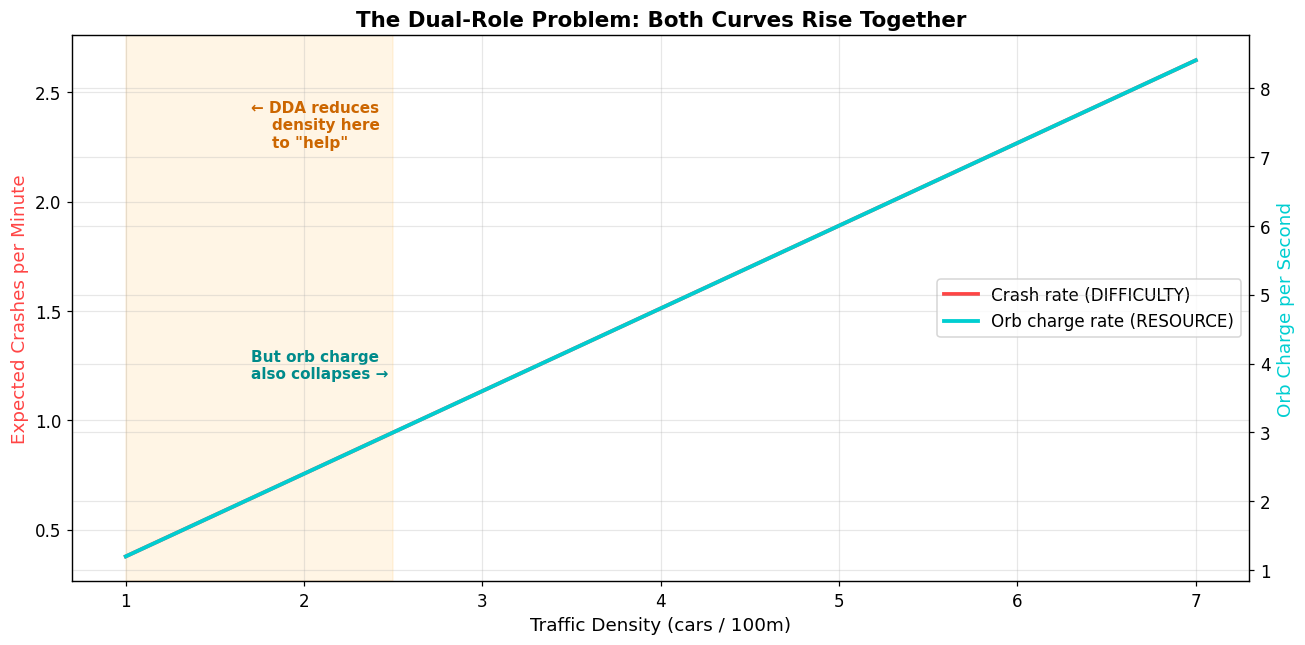

In [22]:
densities_range = np.linspace(1.0, 7.0, 100)
speed = 35.0  # mid-game speed

# Difficulty: crash probability scales with density
crash_probs = [d * speed / 100 * cfg.base_crash_chance * 60
               for d in densities_range]

# Resource: orb charge rate scales with density
orb_rates = []
for d in densities_range:
    cars_per_sec = d * speed / 100
    same = cars_per_sec * (1 - cfg.oncoming_fraction)
    oncoming = cars_per_sec * cfg.oncoming_fraction
    charge = (same * cfg.near_miss_chance_same * cfg.orb_charge_same_dir +
              oncoming * cfg.near_miss_chance_oncoming * cfg.orb_charge_oncoming)
    orb_rates.append(charge)

# --- Graph: Dual Role ---
fig, ax = plt.subplots(figsize=(12, 6))
ax2 = ax.twinx()

line1, = ax.plot(densities_range, crash_probs, color='#FF4444', lw=2.5,
                 label='Crash rate (DIFFICULTY)')
line2, = ax2.plot(densities_range, orb_rates, color='#00CED1', lw=2.5,
                  label='Orb charge rate (RESOURCE)')

ax.set_xlabel('Traffic Density (cars / 100m)', fontsize=12)
ax.set_ylabel('Expected Crashes per Minute', color='#FF4444', fontsize=12)
ax2.set_ylabel('Orb Charge per Second', color='#00CED1', fontsize=12)
ax.set_title('The Dual-Role Problem: Both Curves Rise Together',
             fontsize=14, fontweight='bold')

ax.axvspan(1.0, 2.5, alpha=0.1, color='orange')
ax.text(1.7, max(crash_probs)*0.85,
        '← DDA reduces\n    density here\n    to "help"',
        fontsize=10, color='#CC6600', fontweight='bold')
ax.text(1.7, max(crash_probs)*0.45,
        'But orb charge\nalso collapses →',
        fontsize=10, color='#008B8B', fontweight='bold')

ax.legend([line1, line2], [line1.get_label(), line2.get_label()],
          loc='center right', fontsize=11)
plt.tight_layout()
plt.show()

## 4. DDA Implementations — Naive vs. Coupling-Aware

### Design Decision: Step-based intervention, not continuous scaling

Each time the player dies before 3,000m, the DDA intervenes **once**. This mirrors how many production DDA systems work — discrete adjustments after observable failure events.

Two controllers, exactly as described in the essay:

| Controller | What it adjusts | What it protects |
|---|---|---|
| **NaiveDDA** | Traffic density (−0.15/death, floor 0.4) | Nothing |
| **CouplingAwareDDA** | Gap width (+8%), barrier freq (−1 tier) | Traffic density (always 1.0) |

In [23]:
class NaiveDDA:
    """
    FAILURE CASE: Reduces traffic density by 0.15 per death before Stage 3.
    Floor at 0.4x baseline.
    """
    def __init__(self):
        self.density_multiplier = 1.0
        self.gap_width_multiplier = 1.0
        self.barrier_freq_multiplier = 1.0
        self.oncoming_fraction = cfg.oncoming_fraction
        self.interventions = 0

    def on_death(self, distance: float):
        if distance < cfg.stage_3_start:
            self.density_multiplier = max(0.4, self.density_multiplier - 0.15)
            self.interventions += 1

    def get_effective_density(self, base_density):
        return base_density * self.density_multiplier

    def get_effective_gap(self):
        return cfg.base_gap_width * self.gap_width_multiplier

    def get_barrier_freq(self):
        return cfg.base_barrier_freq * self.barrier_freq_multiplier

    def get_oncoming_fraction(self):
        return self.oncoming_fraction

print("✓ NaiveDDA loaded")
print("  Reduces traffic density by 0.15 per death (floor 0.4)")

✓ NaiveDDA loaded
  Reduces traffic density by 0.15 per death (floor 0.4)


In [24]:
class CouplingAwareDDA:
    """
    CORRECT APPROACH: Adjusts only SAFE parameters.
    Traffic density is NEVER reduced — protects the orb pipeline.
    """
    def __init__(self):
        self.density_multiplier = 1.0    # always 1.0 — PROTECTED
        self.gap_width_multiplier = 1.0
        self.barrier_freq_multiplier = 1.0
        self.oncoming_fraction = cfg.oncoming_fraction
        self.interventions = 0

    def on_death(self, distance: float):
        if distance < cfg.stage_3_start:
            self.gap_width_multiplier = min(1.5, self.gap_width_multiplier + 0.08)
            self.barrier_freq_multiplier = max(0.0, self.barrier_freq_multiplier - 0.25)
            self.interventions += 1

    def get_effective_density(self, base_density):
        return base_density * self.density_multiplier  # always unmodified

    def get_effective_gap(self):
        return cfg.base_gap_width * self.gap_width_multiplier

    def get_barrier_freq(self):
        return cfg.base_barrier_freq * self.barrier_freq_multiplier

    def get_oncoming_fraction(self):
        return self.oncoming_fraction

    # ============================================
    # MANDATORY HUMAN DECISION NODE
    #
    # AI proposed: A single DDA controller that uniformly reduces all
    #   difficulty parameters — including traffic density — when the
    #   player struggles. This is the standard approach in DDA tutorials,
    #   GDC talks, and the initial implementation suggested when I asked
    #   for help designing the system.
    #
    # I rejected/modified because: In Cyber Drift Infinite, traffic
    #   density is NOT a single-purpose parameter. It feeds TWO pipelines:
    #   (1) DIFFICULTY — more cars = more collision threats
    #   (2) RESOURCE — more cars = more near-miss opportunities = orb charge
    #   Reducing density severs the player's ONLY path to Rage Mode.
    #   The DDA is "helping the player walk further into a desert while
    #   removing the water."
    #
    # My decision: Built CouplingAwareDDA that classifies parameters by
    #   coupling risk BEFORE the DDA touches anything:
    #   - SAFE (gap width, barrier freq): scale freely
    #   - PARTIALLY COUPLED (oncoming ratio): adjustable within bounds
    #   - FULLY COUPLED (traffic density): NEVER reduce below baseline
    #   The density_multiplier stays at 1.0. The orb pipeline is protected.
    # ============================================

print("✓ CouplingAwareDDA loaded (with Human Decision Node)")
print("  Adjusts gap width (+8%) and barrier freq only")
print("  Traffic density: PROTECTED — always 1.0")

✓ CouplingAwareDDA loaded (with Human Decision Node)
  Adjusts gap width (+8%) and barrier freq only
  Traffic density: PROTECTED — always 1.0


## 5. Simulation Engine

### Design Decision: Simulating successive runs, not one continuous session

The starvation spiral emerges **across multiple runs**. The player dies, restarts, and encounters a modified road. The DDA state persists between runs.

Each "run" simulates the player driving from 0m until they crash. We record:
- **Distance at death** — how far the player got
- **Orb at death** — how charged their orb was when they died

The starvation signature: distance ↑ while orb ↓

In [14]:
@dataclass
class RunResult:
    """Outcome of a single play session."""
    distance_at_death: float
    orb_at_death: float
    max_orb_reached: float
    rage_activations: int
    density_multiplier: float
    gap_multiplier: float
    barrier_multiplier: float
    oncoming_fraction_used: float
    near_misses_total: int
    cause_of_death: str

def simulate_run(dda, player_skill=0.5, seed=42):
    """Simulate one run. Returns when the player dies."""
    rng = np.random.RandomState(seed)

    distance = 0.0
    orb = 0.0
    rage_timer = 0.0
    rage_count = 0
    near_misses = 0
    max_orb = 0.0
    dt = 0.5

    oncoming_frac = dda.get_oncoming_fraction()

    for tick in range(2000):
        speed = speed_curve(distance)
        base_density = base_traffic_density(distance)
        eff_density = dda.get_effective_density(base_density)
        gap_mult = dda.get_effective_gap()

        # Cars encountered this tick
        cars = max(0, rng.poisson(eff_density * speed / 100.0 * dt))
        oncoming = int(cars * oncoming_frac)
        same_dir = cars - oncoming

        # Near-miss & orb charge
        orb_gain = 0.0
        if rage_timer <= 0:
            gap_penalty = 1.0 / gap_mult

            for _ in range(same_dir):
                if rng.random() < cfg.near_miss_chance_same * (0.5 + player_skill * 0.7) * gap_penalty:
                    orb_gain += cfg.orb_charge_same_dir
                    near_misses += 1
            for _ in range(oncoming):
                if rng.random() < cfg.near_miss_chance_oncoming * (0.5 + player_skill * 0.7) * gap_penalty:
                    orb_gain += cfg.orb_charge_oncoming
                    near_misses += 1

        orb = min(cfg.orb_max, orb + orb_gain)
        max_orb = max(max_orb, orb)

        # Rage Mode
        if orb >= cfg.orb_max and rage_timer <= 0:
            rage_timer = cfg.rage_duration
            orb = 0.0
            rage_count += 1
        if rage_timer > 0:
            rage_timer -= dt

        # Crash check
        if rage_timer <= 0:
            speed_factor = speed / cfg.max_speed
            crash_mod = 1.0 / gap_mult
            barrier_mod = dda.get_barrier_freq() / cfg.base_barrier_freq
            crash_chance = (cfg.base_crash_chance * speed_factor *
                           (1.4 - player_skill * 0.8) *
                           crash_mod * (0.7 + 0.3 * barrier_mod))

            for _ in range(cars):
                if rng.random() < crash_chance * dt:
                    dda.on_death(distance)
                    return RunResult(distance, orb, max_orb, rage_count,
                                    dda.density_multiplier, dda.gap_width_multiplier,
                                    dda.barrier_freq_multiplier, oncoming_frac,
                                    near_misses, "crash")

            # Stage 3: no-safe-lane formations
            if distance >= cfg.stage_3_start:
                if rng.random() < cfg.no_safe_lane_chance_per_sec * dt:
                    if rage_timer <= 0 and orb < cfg.orb_max:
                        dda.on_death(distance)
                        return RunResult(distance, orb, max_orb, rage_count,
                                        dda.density_multiplier, dda.gap_width_multiplier,
                                        dda.barrier_freq_multiplier, oncoming_frac,
                                        near_misses, "no_rage_at_formation")

        distance += speed * dt

    return RunResult(distance, orb, max_orb, rage_count,
                     dda.density_multiplier, dda.gap_width_multiplier,
                     dda.barrier_freq_multiplier, oncoming_frac,
                     near_misses, "survived")

def simulate_multiple_runs(dda_class, num_runs=8, player_skill=0.5, base_seed=42):
    """Simulate successive runs. DDA state persists across runs."""
    dda = dda_class()
    results = []
    for i in range(num_runs):
        result = simulate_run(dda, player_skill=player_skill, seed=base_seed + i * 7)
        results.append(result)
    return results

print("✓ Simulation engine ready")
print("  simulate_run() — one session until death")
print("  simulate_multiple_runs() — 8 successive sessions with persistent DDA")

✓ Simulation engine ready
  simulate_run() — one session until death
  simulate_multiple_runs() — 8 successive sessions with persistent DDA


## 6. ⚠️ The Starvation Spiral — Failure Case (Triggered & Observed)

**This is the deliberate failure case.**

8 successive runs under **Naive DDA**. Each death reduces traffic density by 0.15.

**Watch for the telemetry signature:** survival distance INCREASES while orb charge at death DECREASES.

> *"The player is living longer and arriving weaker — walking further into a desert while removing the water."*

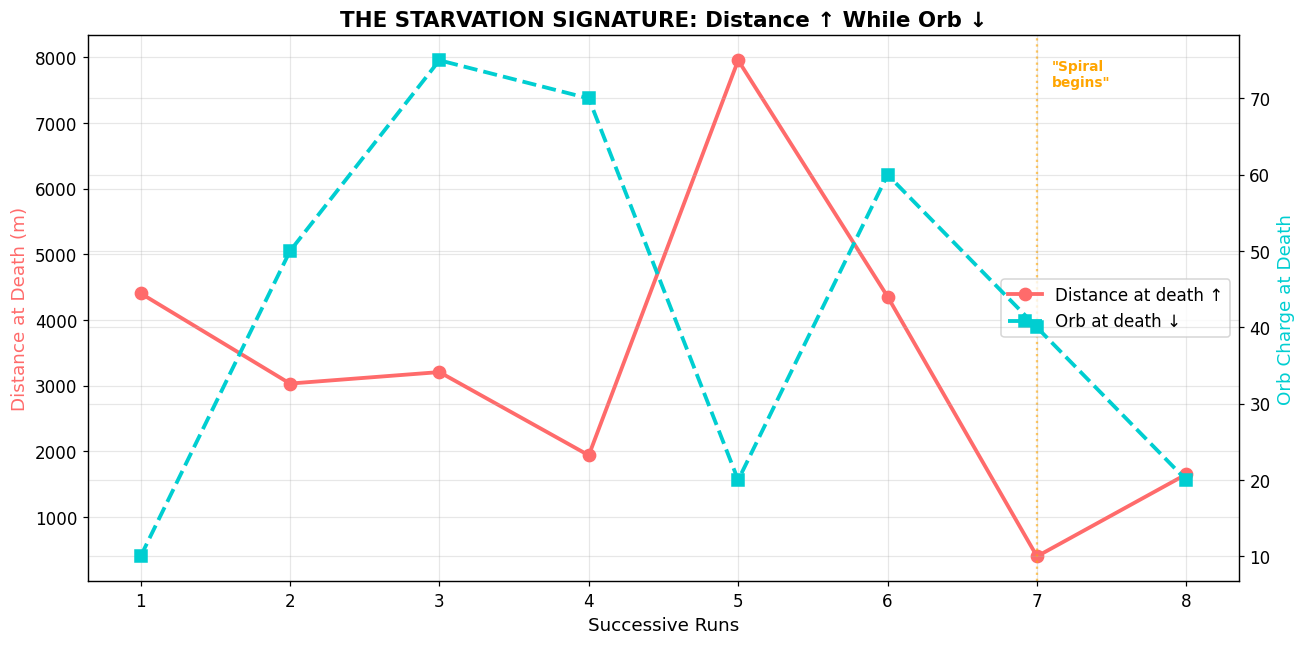

In [25]:
naive_results = simulate_multiple_runs(NaiveDDA, num_runs=8, player_skill=0.5, base_seed=42)

runs = list(range(1, 9))
distances = [r.distance_at_death for r in naive_results]
orbs = [r.orb_at_death for r in naive_results]
densities = [r.density_multiplier for r in naive_results]

# --- Graph: The Telemetry Signature ---
fig, ax = plt.subplots(figsize=(12, 6))
ax2_twin = ax.twinx()

line1, = ax.plot(runs, distances, 'o-', color='#FF6B6B', lw=2.5, ms=8,
                 label='Distance at death ↑')
line2, = ax2_twin.plot(runs, orbs, 's--', color='#00CED1', lw=2.5, ms=8,
                       label='Orb at death ↓')

ax.set_xlabel('Successive Runs', fontsize=12)
ax.set_ylabel('Distance at Death (m)', color='#FF6B6B', fontsize=12)
ax2_twin.set_ylabel('Orb Charge at Death', color='#00CED1', fontsize=12)
ax.set_title('THE STARVATION SIGNATURE: Distance ↑ While Orb ↓',
             fontsize=14, fontweight='bold')
ax.legend([line1, line2], [line1.get_label(), line2.get_label()], loc='center right')

for i, r in enumerate(naive_results):
    if r.density_multiplier < 0.85:
        ax.axvline(i + 1, color='orange', ls=':', alpha=0.6)
        ax.text(i + 1.1, max(distances) * 0.95, '"Spiral\nbegins"',
                fontsize=9, color='orange', fontweight='bold')
        break

plt.tight_layout()
plt.show()

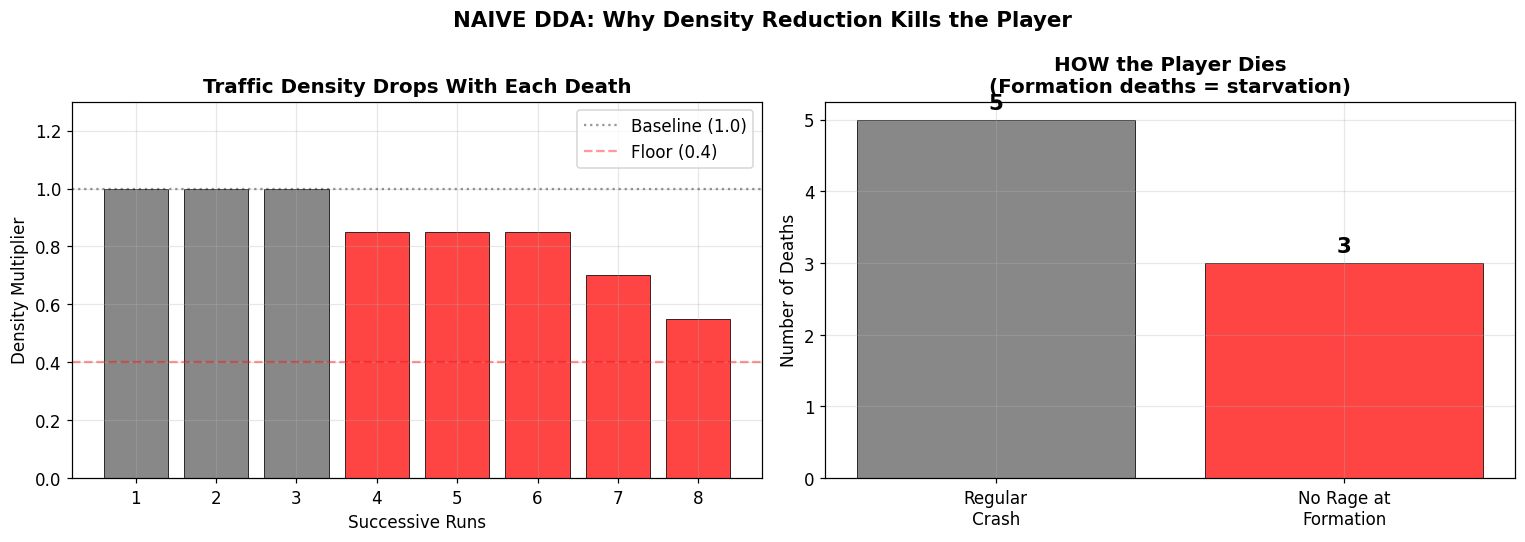


NAIVE DDA — Run-by-Run Results
Run   Distance    Orb@Death   Density   Rage    Cause
--------------------------------------------------------------------------------
1     4405        10.0        1.00      5       crash
2     3030        50.0        1.00      2       no_rage_at_formation
3     3205        75.0        1.00      3       crash
4     1937        70.0        0.85      1       crash
5     7955        20.0        0.85      8       no_rage_at_formation
6     4355        60.0        0.85      4       no_rage_at_formation
7     398         40.0        0.70      0       crash
8     1649        20.0        0.55      1       crash


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Graph: Density multiplier declining ---
colors_bar = ['#FF4444' if d < 1.0 else '#888888' for d in densities]
ax1.bar(runs, densities, color=colors_bar, edgecolor='black', lw=0.5)
ax1.axhline(1.0, color='black', ls=':', alpha=0.4, label='Baseline (1.0)')
ax1.axhline(0.4, color='red', ls='--', alpha=0.4, label='Floor (0.4)')
ax1.set_xlabel('Successive Runs')
ax1.set_ylabel('Density Multiplier')
ax1.set_title('Traffic Density Drops With Each Death', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 1.3)
ax1.legend()

# --- Graph: How the player dies ---
crash_deaths = sum(1 for r in naive_results if r.cause_of_death == "crash")
formation_deaths = sum(1 for r in naive_results if r.cause_of_death == "no_rage_at_formation")

bars = ax2.bar(['Regular\nCrash', 'No Rage at\nFormation'],
               [crash_deaths, formation_deaths],
               color=['#888888', '#FF4444'], edgecolor='black', lw=0.5)
ax2.set_ylabel('Number of Deaths')
ax2.set_title('HOW the Player Dies\n(Formation deaths = starvation)', fontsize=13, fontweight='bold')

for bar, val in zip(bars, [crash_deaths, formation_deaths]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             str(val), ha='center', fontweight='bold', fontsize=14)

plt.suptitle('NAIVE DDA: Why Density Reduction Kills the Player',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Detailed run-by-run table ---
print("\n" + "=" * 80)
print("NAIVE DDA — Run-by-Run Results")
print("=" * 80)
print(f"{'Run':<6}{'Distance':<12}{'Orb@Death':<12}{'Density':<10}{'Rage':<8}{'Cause'}")
print("-" * 80)
for i, r in enumerate(naive_results):
    print(f"{i+1:<6}{r.distance_at_death:<12.0f}{r.orb_at_death:<12.1f}"
          f"{r.density_multiplier:<10.2f}{r.rage_activations:<8}{r.cause_of_death}")
print("=" * 80)

## 7. Naive DDA vs. Coupling-Aware DDA — Side by Side

Same player skill, same random seeds, same number of runs.  
The **ONLY** difference is which parameters the DDA adjusts.

| | Naive DDA | Coupling-Aware DDA |
|---|---|---|
| Touches density? | ✅ Yes (reduces) | ❌ No (protected) |
| Orb starves? | ✅ Yes | ❌ No |
| Formation deaths? | ✅ Many | ❌ Few/none |

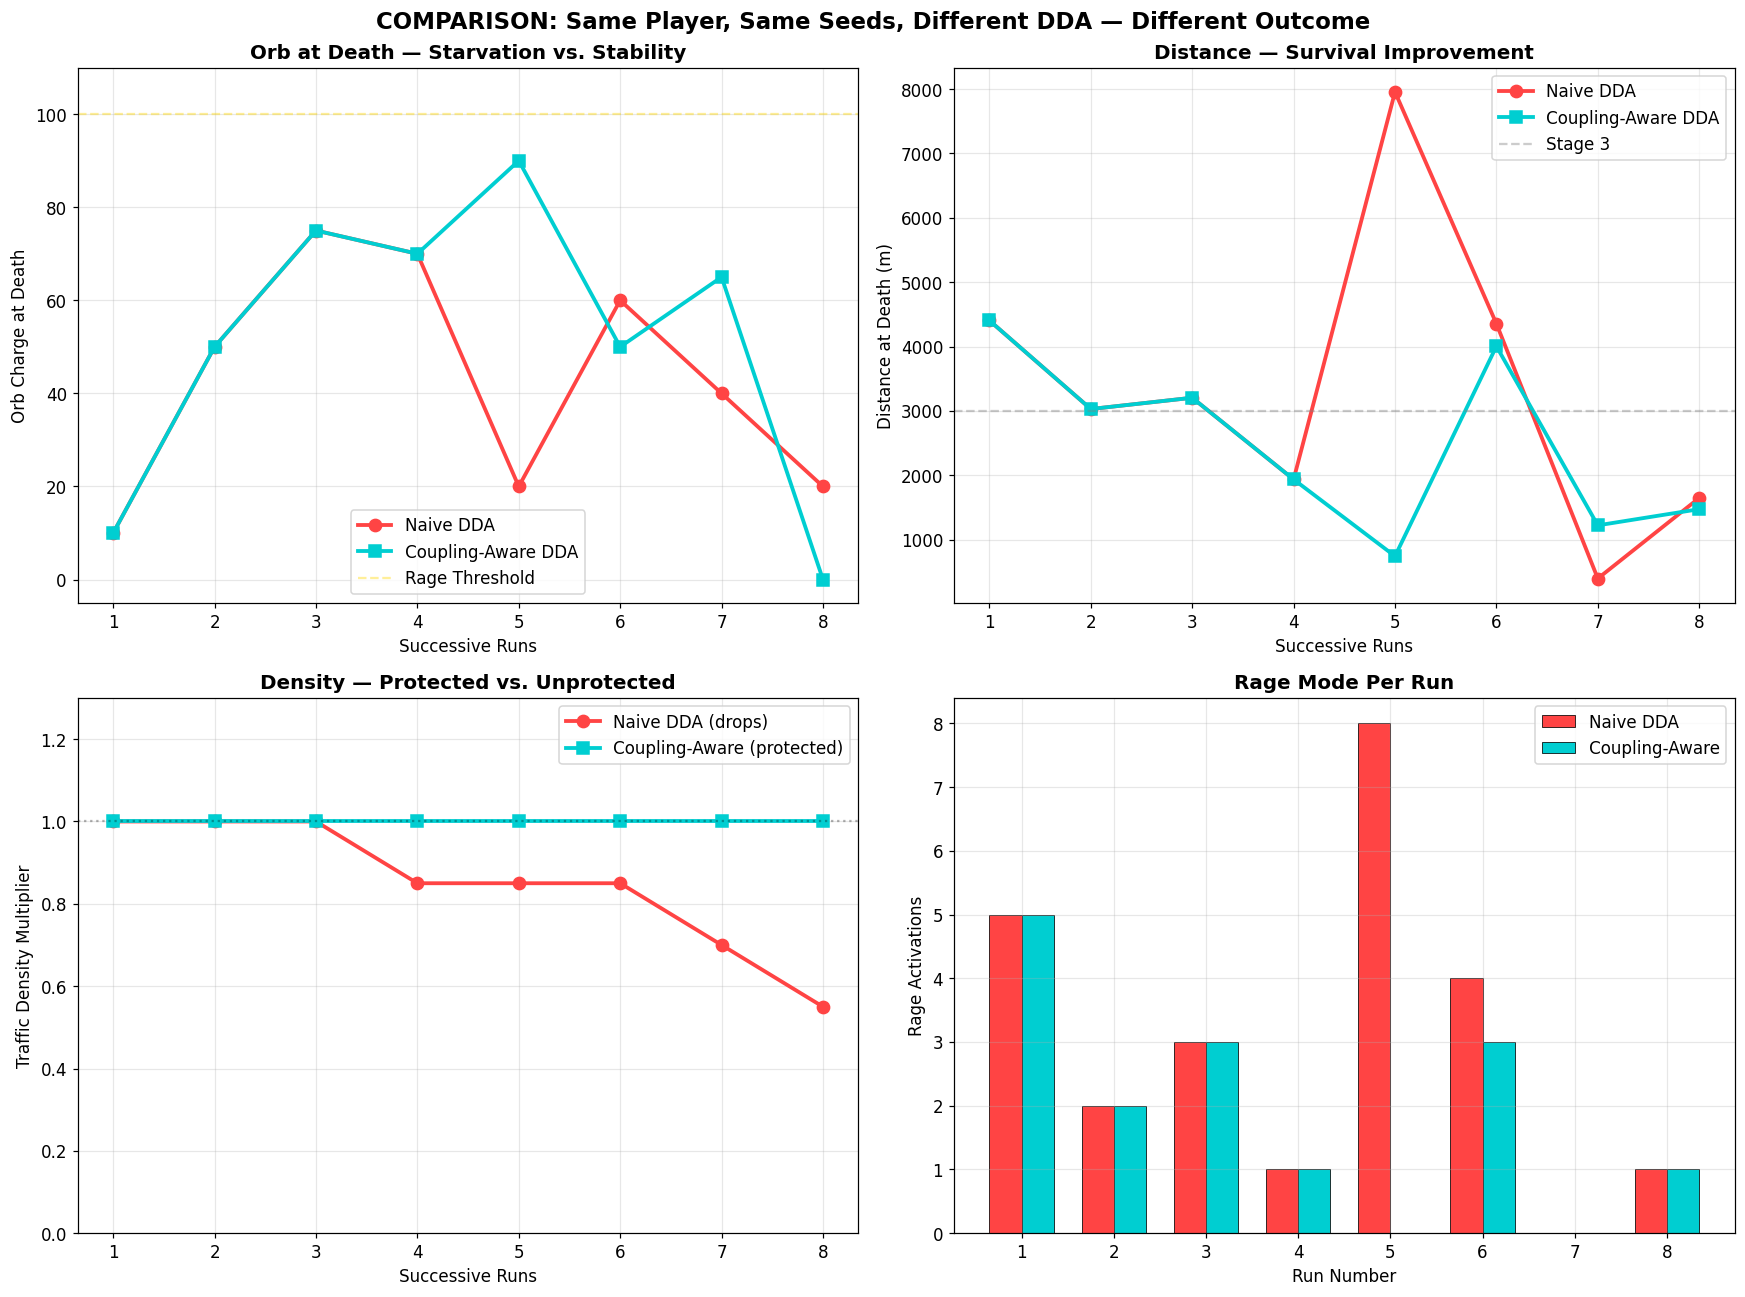


SUMMARY COMPARISON
Metric                             Naive DDA         Coupling-Aware
----------------------------------------------------------------------
Avg orb at death                   43.1              51.2
Total Rage activations             24                15
Deaths at formations               3                 2
Final density multiplier           0.55              1.00 (protected)


In [17]:
naive_results = simulate_multiple_runs(NaiveDDA, num_runs=8, player_skill=0.5, base_seed=42)
aware_results = simulate_multiple_runs(CouplingAwareDDA, num_runs=8, player_skill=0.5, base_seed=42)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
runs = list(range(1, 9))

# --- Top-left: Orb at death (THE KEY CHART) ---
ax = axes[0, 0]
ax.plot(runs, [r.orb_at_death for r in naive_results], 'o-', color='#FF4444',
        lw=2.5, ms=8, label='Naive DDA')
ax.plot(runs, [r.orb_at_death for r in aware_results], 's-', color='#00CED1',
        lw=2.5, ms=8, label='Coupling-Aware DDA')
ax.axhline(100, color='gold', ls='--', alpha=0.4, label='Rage Threshold')
ax.set_xlabel('Successive Runs')
ax.set_ylabel('Orb Charge at Death')
ax.set_title('Orb at Death — Starvation vs. Stability', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(-5, 110)

# --- Top-right: Distance at death ---
ax = axes[0, 1]
ax.plot(runs, [r.distance_at_death for r in naive_results], 'o-', color='#FF4444',
        lw=2.5, ms=8, label='Naive DDA')
ax.plot(runs, [r.distance_at_death for r in aware_results], 's-', color='#00CED1',
        lw=2.5, ms=8, label='Coupling-Aware DDA')
ax.axhline(3000, color='gray', ls='--', alpha=0.4, label='Stage 3')
ax.set_xlabel('Successive Runs')
ax.set_ylabel('Distance at Death (m)')
ax.set_title('Distance — Survival Improvement', fontsize=13, fontweight='bold')
ax.legend()

# --- Bottom-left: Density multiplier ---
ax = axes[1, 0]
ax.plot(runs, [r.density_multiplier for r in naive_results], 'o-', color='#FF4444',
        lw=2.5, ms=8, label='Naive DDA (drops)')
ax.plot(runs, [1.0]*8, 's-', color='#00CED1',
        lw=2.5, ms=8, label='Coupling-Aware (protected)')
ax.axhline(1.0, color='black', ls=':', alpha=0.3)
ax.set_xlabel('Successive Runs')
ax.set_ylabel('Traffic Density Multiplier')
ax.set_title('Density — Protected vs. Unprotected', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.3)

# --- Bottom-right: Rage activations ---
ax = axes[1, 1]
x = np.arange(8)
w = 0.35
ax.bar(x - w/2, [r.rage_activations for r in naive_results], w, color='#FF4444',
       label='Naive DDA', edgecolor='black', lw=0.5)
ax.bar(x + w/2, [r.rage_activations for r in aware_results], w, color='#00CED1',
       label='Coupling-Aware', edgecolor='black', lw=0.5)
ax.set_xlabel('Run Number')
ax.set_ylabel('Rage Activations')
ax.set_xticks(x)
ax.set_xticklabels(runs)
ax.set_title('Rage Mode Per Run', fontsize=13, fontweight='bold')
ax.legend()

plt.suptitle('COMPARISON: Same Player, Same Seeds, Different DDA — Different Outcome',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Summary stats ---
print("\n" + "=" * 70)
print("SUMMARY COMPARISON")
print("=" * 70)
print(f"{'Metric':<35}{'Naive DDA':<18}{'Coupling-Aware'}")
print("-" * 70)
print(f"{'Avg orb at death':<35}"
      f"{np.mean([r.orb_at_death for r in naive_results]):<18.1f}"
      f"{np.mean([r.orb_at_death for r in aware_results]):.1f}")
print(f"{'Total Rage activations':<35}"
      f"{sum(r.rage_activations for r in naive_results):<18}"
      f"{sum(r.rage_activations for r in aware_results)}")
print(f"{'Deaths at formations':<35}"
      f"{sum(1 for r in naive_results if r.cause_of_death=='no_rage_at_formation'):<18}"
      f"{sum(1 for r in aware_results if r.cause_of_death=='no_rage_at_formation')}")
print(f"{'Final density multiplier':<35}"
      f"{naive_results[-1].density_multiplier:<18.2f}{'1.00 (protected)'}")
print("=" * 70)

## 8. 🧪 The Exercise — Test the Partially Coupled Parameter

The CouplingAwareDDA adjusts only **safe** parameters. But what about **partially coupled** ones?

The **oncoming-to-same-direction ratio** is partially coupled: shifting the mix toward same-direction traffic reduces danger (lower closing speed) but also reduces orb charge per encounter (+10 instead of +15).

**Your task:** Change `oncoming_ratio_shift` in the cell below and re-run. Find the threshold (~30–40% reduction) where the starvation spiral re-emerges.

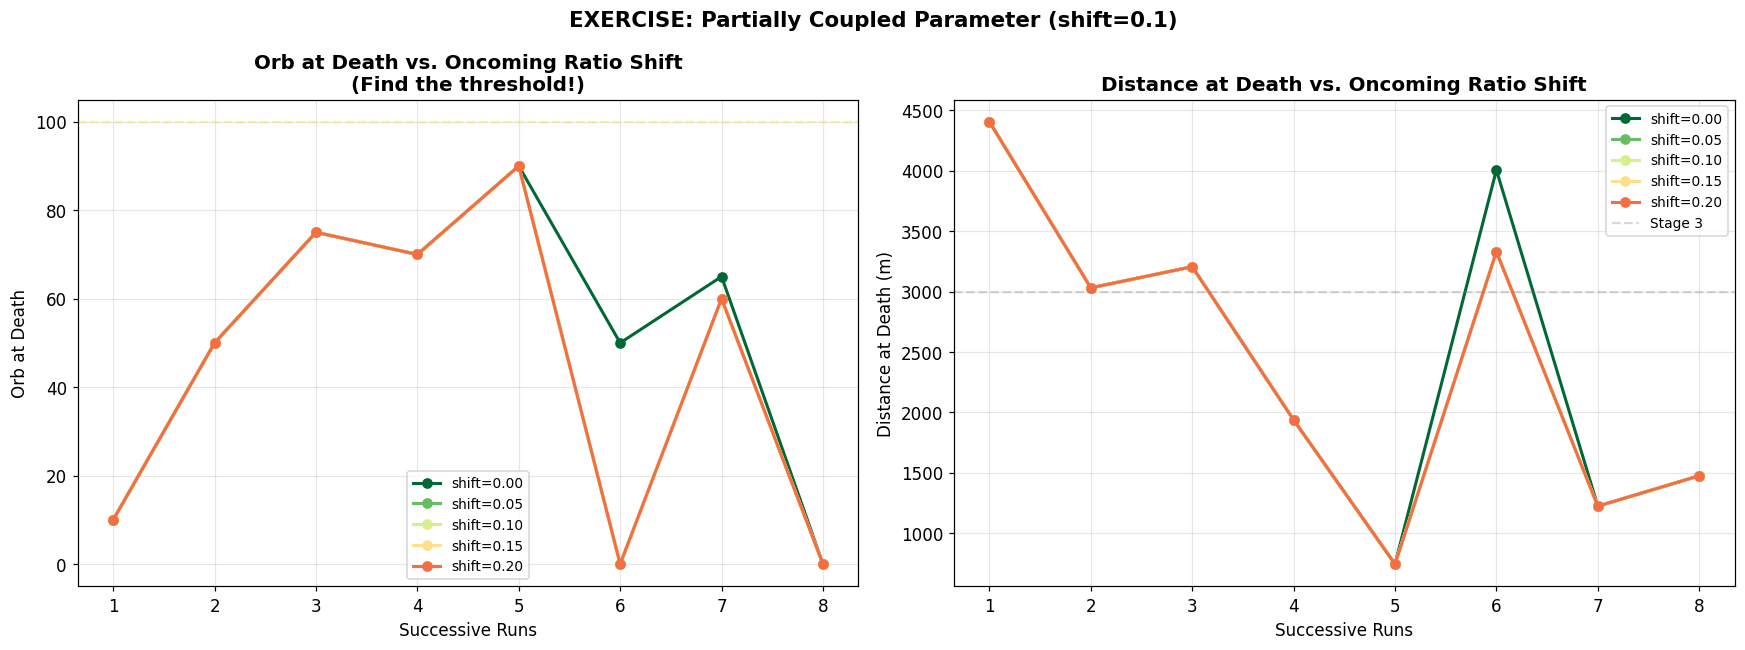


Current shift = 0.1
Baseline oncoming fraction = 0.35

→ Change 'oncoming_ratio_shift' above and re-run to find the threshold.


In [18]:
# ==============================
# ← MODIFY THIS VALUE AND RE-RUN
oncoming_ratio_shift = 0.10
# ==============================

class CouplingAwareDDA_WithRatio:
    """Extended DDA that also shifts oncoming ratio — tests partial coupling."""
    def __init__(self, ratio_shift=0.10):
        self.density_multiplier = 1.0
        self.gap_width_multiplier = 1.0
        self.barrier_freq_multiplier = 1.0
        self.oncoming_fraction = cfg.oncoming_fraction
        self.ratio_shift = ratio_shift
        self.interventions = 0

    def on_death(self, distance):
        if distance < cfg.stage_3_start:
            self.gap_width_multiplier = min(1.5, self.gap_width_multiplier + 0.08)
            self.barrier_freq_multiplier = max(0.0, self.barrier_freq_multiplier - 0.25)
            self.oncoming_fraction = max(0.05, self.oncoming_fraction - self.ratio_shift)
            self.interventions += 1

    def get_effective_density(self, base_density):
        return base_density * self.density_multiplier

    def get_effective_gap(self):
        return cfg.base_gap_width * self.gap_width_multiplier

    def get_barrier_freq(self):
        return cfg.base_barrier_freq * self.barrier_freq_multiplier

    def get_oncoming_fraction(self):
        return self.oncoming_fraction


# Run across multiple shift values
shifts_to_test = sorted(set([0.00, 0.05, oncoming_ratio_shift, 0.15, 0.20]))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for shift in shifts_to_test:
    dda = CouplingAwareDDA_WithRatio(ratio_shift=shift)
    results = [simulate_run(dda, player_skill=0.5, seed=42 + i * 7) for i in range(8)]

    label = f'shift={shift:.2f}'
    color = plt.cm.RdYlGn(1.0 - shift / 0.25) if shift <= 0.25 else 'red'

    ax1.plot(range(1, 9), [r.orb_at_death for r in results],
             'o-', lw=2, ms=6, label=label, color=color)
    ax2.plot(range(1, 9), [r.distance_at_death for r in results],
             'o-', lw=2, ms=6, label=label, color=color)

ax1.axhline(100, color='gold', ls='--', alpha=0.3)
ax1.set_xlabel('Successive Runs')
ax1.set_ylabel('Orb at Death')
ax1.set_title('Orb at Death vs. Oncoming Ratio Shift\n(Find the threshold!)',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

ax2.axhline(3000, color='gray', ls='--', alpha=0.3, label='Stage 3')
ax2.set_xlabel('Successive Runs')
ax2.set_ylabel('Distance at Death (m)')
ax2.set_title('Distance at Death vs. Oncoming Ratio Shift',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle(f'EXERCISE: Partially Coupled Parameter (shift={oncoming_ratio_shift})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nCurrent shift = {oncoming_ratio_shift}")
print(f"Baseline oncoming fraction = {cfg.oncoming_fraction:.2f}")
print(f"\n→ Change 'oncoming_ratio_shift' above and re-run to find the threshold.")